**Dataset Preparation**
1. Dataset Choice
For this assignment, we use Project Gutenberg texts (public domain books).
Example:

Pride and Prejudice by Jane Austen
https://www.gutenberg.org/

Justification:

Freely available
Rich narrative structure
Suitable for simple text generation tasks


2. Data Preprocessing
Steps includes:

Lowercasing text
Removing unwanted symbols
Character-level tokenization
Creating input-output text sequences


3. Methodology: Hands-On Model Implementation
Tools and Libraries

Python
TensorFlow / Keras
NumPy
Matplotlib

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [13]:
# Load dataset
with open("gutenberg_text.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()

# Create character vocabulary
chars = sorted(list(set(text)))
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

SEQ_LENGTH = 40
STEP = 3

X = []
y = []

for i in range(0, len(text) - SEQ_LENGTH, STEP):
    X.append([char_to_idx[c] for c in text[i:i+SEQ_LENGTH]])
    y.append(char_to_idx[text[i+SEQ_LENGTH]])

X = np.array(X)
y = np.array(y)

Model **Architecture**

In [14]:
model = Sequential([
    Embedding(len(chars), 64, input_length=SEQ_LENGTH),
    LSTM(128),
    Dense(len(chars), activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training

In [15]:
history = model.fit(
    X, y,
    batch_size=128,
    epochs=10
)

Epoch 1/10
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 244s 124ms/step - loss: 2.3397
Epoch 2/10
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 240s 123ms/step - loss: 1.9517
Epoch 3/10
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 240s 123ms/step - loss: 1.7934
Epoch 4/10
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 240s 123ms/step - loss: 1.6897
Epoch 5/10
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 240s 123ms/step - loss: 1.6158
Epoch 6/10
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 241s 124ms/step - loss: 1.5601
Epoch 7/10
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 240s 123ms/step - loss: 1.5152
Epoch 8/10
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 240s 123ms/step - loss: 1.4781
Epoch 9/10
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 262s 123ms/step - loss: 1.4488
Epoch 10/10
1949/1949 ━━━━━━━━━━━━━━━━━━━━ 262s 123ms/step - loss: 1.4231


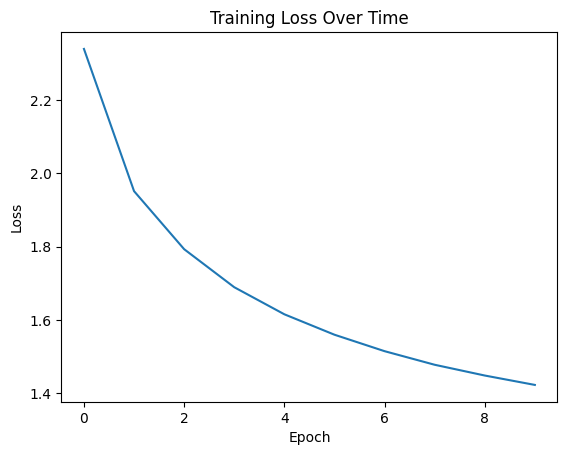

In [17]:
plt.plot(history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.show()

Application Demonstration: Content **Creation**

In [18]:
def generate_text(seed, length=300):
    generated = seed.lower()

    for _ in range(length):
        input_seq = [char_to_idx[c] for c in generated[-SEQ_LENGTH:]]
        input_seq = np.array(input_seq).reshape(1, -1)
        probs = model.predict(input_seq, verbose=0)[0]
        next_char = np.random.choice(len(chars), p=probs)
        generated += idx_to_char[next_char]

    return generated

In [19]:
print(generate_text("it is a truth universally acknowledged"))

it is a truth universally acknowledged
are in the prouvo lucasme, mary famsections gode her commirits and a formottle fexe any moment
bettle his mauram un his rame of mr.” rarrined one contonity miss.”









                   illmak but him with aa very one her forgards.

convery as. i will spart, the comans leave expressiond lucada


# Generative AI Text Generation using GPT Concepts

This project explores **Generative Artificial Intelligence (AI)** fundamentals through the design, training, and evaluation of a **text generation model inspired by Generative Pre‑trained Transformers (GPTs)**. It combines theoretical understanding with hands‑on implementation using Python and TensorFlow/Keras.

The project was developed and executed in **Google Colab** for reproducibility and ease of use.

---

## Project Objectives

- Understand the core concepts of **Generative AI**
- Explore the **architecture and functioning of GPT models**
- Train a basic **text generation model** on a public dataset
- Demonstrate a **content creation application**
- Discuss **ethical implications** of generative models

---

## Key Concepts Covered

- Generative vs Discriminative Models  
- Transformer Architecture  
- Self‑Attention Mechanism  
- Tokenization and Sequence Modeling  
- Probabilistic Text Generation  
- Ethical Considerations in AI  

---

## Dataset

**Source:** Project Gutenberg (Public Domain)  
**Example Text:** *Pride and Prejudice* by Jane Austen  

The dataset is used to train a **character‑level language model**, allowing the model to learn linguistic patterns and generate new text sequences.

📎 Dataset link:  
http://www.gutenberg.org/

---

## Project Structure